# Data preparation

You can start to use PyGap in two primary data formats:

* Sequential data represented by numeric epoch indices.
* Time-series data stored in a Pandas DataFrame with a datetime column or datetime index.


## Sequential data

### Sequential data in EigenSig

In the EigenSig model, users should prepare observed data for model training and continous sequential number for gap filling. 
For example, if N-p observed epochs are available (p is number of lost epochs) and there are M obsevation points in each epoch, 
we can stack the observed data into a Y_[N-p, M) matrix. 
The sequential epoch number t[N-p] of observation is the eclipsed time of each observed epochs from start poin (0), t should 
look like: 
t[0, 3, 4, 7,...N] in which 1,2 5,6 epochs are not available or bad observations, 

There are p  missing epochs in t[...]. The y[(n-p)*M] of observations is flattened as a 1-D array from y[N-p,M] 
Then user can create and fit EigenSig model using t[...] and y[...]: 
```python

gf = EigenSig.GapFilling()
gf.fit(t,y)

```
To predict or fill the lost p rows, prepare a epoch sequential data as T[N], such as [0,1, 2, 3, ..., N], then use object gf  
to get predicted Y_pred[N]. 
```python
Y_pred = gf.predict(T, inter1D='slinear', filtStr='0:')  
```
Y_pred is a 1D array has N epochs. Then we get filled reaults (T,Y_pred).

The inter1D is used to select available 1D coordinate tracing in the Eigenspace. Its possible values could be find in DemoEigenSig.ipynb

FillStr is a basis selection parameter in the Eigenspace similar to index slicing in NumPy, default is [0:] which means use all basis in 
Eigenspace. [1:] and [3:15] are using basis from the second and within 3^th and 15^th in the eigenspace gap filling, respectively.      

Sequential data example used in the DemoEigenSig.ipynb, the first column (marked with yellow) is the vector t[] and others are Y[14,24], the vector y[]= Y.flattern(). in the first column, yellow marks show lost data epoch (gaps). the T[] used in the predict() is T[0,1,2,3,...31], a continous series.
See eigenData_example.csv or eigenData_example.xlsx file in the project. 
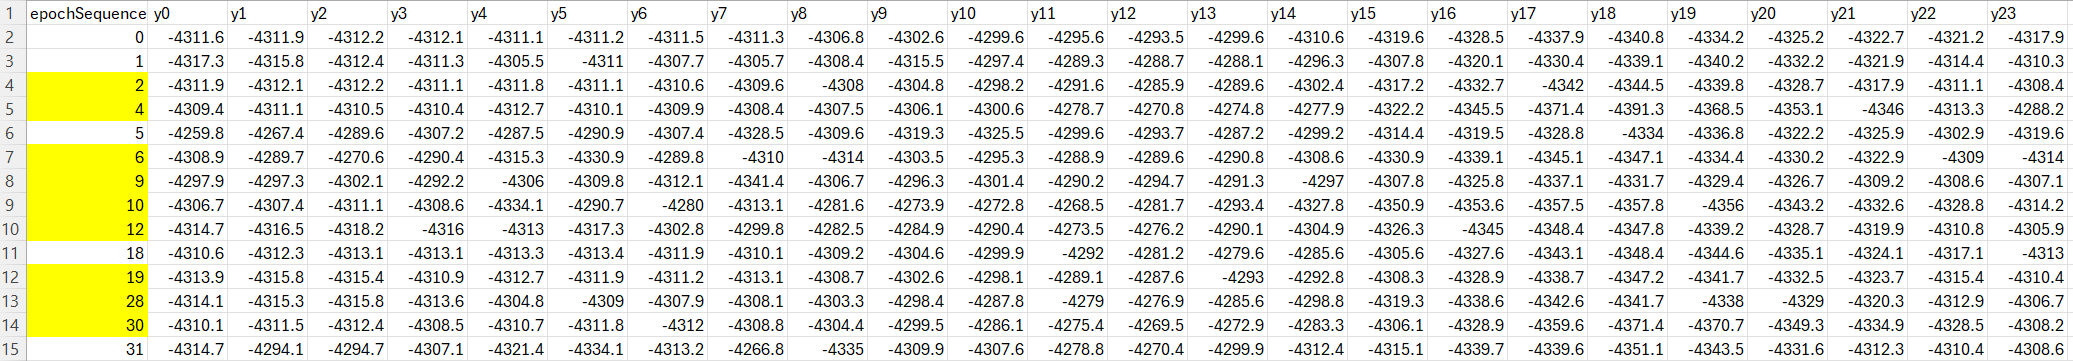


### Sequencial data in LSHE
The observed data t[n], y[n] can be directly used training LSHE model. Here t[n] can be uneven. That's the flexibility.
Prepare T[N] with data to be used prediction at T[N]. T[N] coud be uneven, T[0] and T[-1] could out of [[t[0], t[n-1]]. 
It will be a extrapolation challenge if T[...] value is outside [[t[0], t[n-1]].     
```python
from pygap import LSHE
lshe = LSHE()

# Fit the model and detect significant frequencies
lshe.fit(t, y)

# Reconstruct missing observations
y_pred = lshe.predict(T)

```
## Data time data in DataFrame (Pandas)
### EigenSig
Data can be prepared as time series. Prepare a column as standard datatime data type and many other fields with observation.
- the first and last epochs should be fully observed data (if not, find the first and last epochs with full observations)
- each available epoch should be fully observed (if not fully observed, see Fig. 9, 11 that indicate how to use individual 
observations for gap filling and quality control in Li and Liu (2026)).
- the epoch sequntial will be used as t[N-p], such as for houly observed data and we use one day as an epoch, then p is the days
without data (gaps), N is the total days of our working domain. the corresponding observations should be y[(N-p)*epoch] Prediction
at T[N] should be T[0,1,2,...N-1], similar as sequential data. In the DemoEigenSig.ipynb, handling datatime field and transforming
into sequential format had been demonstrated.
### LSHE
LSHE has less rules to follow.
- transform datatime series into data from start value such as df.index[i]-df.index[0] as t[N-p] and simultanneouly extract y[N-p].
Note that df is the input dataframe with unevenly observed data.
- generate a continous or noncontinous time series at time we need to interpolate in a new dataframe df_pred, generate T[N] for this data frame but use
the df.index[0] as its starting time. then use LSHE model to predict values at T[N].
- DemoLSHE.ipynb shows this procedure
